In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import os

drive_path = "/content/drive/MyDrive"

zip_file = None
for root, dirs, files in os.walk(drive_path):
    for file in files:
        if "Turbofan" in file and file.endswith(".zip"):
            zip_file = os.path.join(root, file)

print("✅ Found ZIP file at:")
print(zip_file)


✅ Found ZIP file at:
/content/drive/MyDrive/MACHINE LEARNING /6.+Turbofan+Engine+Degradation+Simulation+Data+Set (2).zip


In [ ]:
import zipfile

extract_path = "/content/dataset"
os.makedirs(extract_path, exist_ok=True)

with zipfile.ZipFile(zip_file, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("✅ Dataset extracted to:", extract_path)
print("📂 Files:", os.listdir(extract_path))


✅ Dataset extracted to: /content/dataset
📂 Files: ['6. Turbofan Engine Degradation Simulation Data Set']


In [ ]:
for f in os.listdir("/content/dataset"):
    print(f)


6. Turbofan Engine Degradation Simulation Data Set


In [ ]:
import os

base_path = "/content/dataset"

print("Top folder contents:")
print(os.listdir(base_path))

inner_folder = os.path.join(base_path, os.listdir(base_path)[0])
print("\nUsing dataset folder:")
print(inner_folder)

print("\nFiles inside dataset folder:")
print(os.listdir(inner_folder))


Top folder contents:
['6. Turbofan Engine Degradation Simulation Data Set']

Using dataset folder:
/content/dataset/6. Turbofan Engine Degradation Simulation Data Set

Files inside dataset folder:
['CMAPSSData.zip']


In [ ]:
import os

dataset_root = "/content/dataset"

for root, dirs, files in os.walk(dataset_root):
    level = root.replace(dataset_root, '').count(os.sep)
    indent = ' ' * 4 * level
    print(f"{indent}📁 {os.path.basename(root)}/")
    subindent = ' ' * 4 * (level + 1)
    for f in files:
        print(f"{subindent}📄 {f}")


📁 dataset/
    📁 6. Turbofan Engine Degradation Simulation Data Set/
        📄 CMAPSSData.zip


In [ ]:
import os

dataset_root = "/content/dataset"

print("\n🔍 FULL DATASET STRUCTURE:\n")

for root, dirs, files in os.walk(dataset_root):
    print(root)
    for f in files:
        print("   📄", f)



🔍 FULL DATASET STRUCTURE:

/content/dataset
/content/dataset/6. Turbofan Engine Degradation Simulation Data Set
   📄 CMAPSSData.zip


In [ ]:
import zipfile, os

inner_zip_path = "/content/dataset/6. Turbofan Engine Degradation Simulation Data Set/CMAPSSData.zip"
final_extract_path = "/content/final_dataset"

os.makedirs(final_extract_path, exist_ok=True)

with zipfile.ZipFile(inner_zip_path, 'r') as zip_ref:
    zip_ref.extractall(final_extract_path)

print("✅ Inner dataset extracted to:", final_extract_path)
print("\n📂 Contents:")
for root, dirs, files in os.walk(final_extract_path):
    print(root)
    for f in files:
        print("   📄", f)


✅ Inner dataset extracted to: /content/final_dataset

📂 Contents:
/content/final_dataset
   📄 test_FD002.txt
   📄 RUL_FD002.txt
   📄 train_FD001.txt
   📄 RUL_FD001.txt
   📄 train_FD003.txt
   📄 test_FD004.txt
   📄 train_FD002.txt
   📄 test_FD003.txt
   📄 readme.txt
   📄 test_FD001.txt
   📄 Damage Propagation Modeling.pdf
   📄 RUL_FD003.txt
   📄 train_FD004.txt
   📄 RUL_FD004.txt


In [ ]:
# Fix RUL file format
rul_df = pd.read_csv(rul_path, sep=' ', header=None)

# Drop empty columns
rul_df.dropna(axis=1, inplace=True)

# Rename column
rul_df.columns = ['RUL']

print("✅ RUL fixed")
print(rul_df.head())
print("RUL shape:", rul_df.shape)


✅ RUL fixed
   RUL
0  112
1   98
2   69
3   82
4   91
RUL shape: (100, 1)


In [ ]:
# ================================
# FINAL ONE-BLOCK CMAPSS PIPELINE
# Predictive Maintenance LSTM
# ================================

# ---- Mount Drive ----
from google.colab import drive
drive.mount('/content/drive')

# ---- Imports ----
import os, zipfile
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping

print("\n🚀 Starting Predictive Maintenance Pipeline...\n")

# ---- Locate Main ZIP in Drive ----
drive_root = "/content/drive/MyDrive"
main_zip = None

for root, dirs, files in os.walk(drive_root):
    for f in files:
        if "turbofan" in f.lower() and f.endswith(".zip"):
            main_zip = os.path.join(root, f)

if main_zip is None:
    raise Exception("❌ Main Turbofan ZIP not found in Drive")

print("✅ Main ZIP found:", main_zip)

# ---- Extract Main ZIP ----
extract_root = "/content/dataset"
os.makedirs(extract_root, exist_ok=True)

with zipfile.ZipFile(main_zip, 'r') as zip_ref:
    zip_ref.extractall(extract_root)

print("✅ Main ZIP extracted")

# ---- Find Inner ZIP (CMAPSSData.zip) ----
inner_zip = None
for root, dirs, files in os.walk(extract_root):
    for f in files:
        if "cmapss" in f.lower() and f.endswith(".zip"):
            inner_zip = os.path.join(root, f)

if inner_zip is None:
    raise Exception("❌ CMAPSSData.zip not found")

print("✅ Inner ZIP found:", inner_zip)

# ---- Extract Inner ZIP ----
final_data_root = "/content/final_dataset"
os.makedirs(final_data_root, exist_ok=True)

with zipfile.ZipFile(inner_zip, 'r') as zip_ref:
    zip_ref.extractall(final_data_root)

print("✅ Inner ZIP extracted")

# ---- Detect FD001 Files ----
train_path = test_path = rul_path = None

for root, dirs, files in os.walk(final_data_root):
    for f in files:
        name = f.lower()
        full = os.path.join(root, f)
        if "train_fd001" in name:
            train_path = full
        elif "test_fd001" in name:
            test_path = full
        elif "rul_fd001" in name:
            rul_path = full

if train_path is None or test_path is None or rul_path is None:
    raise Exception("❌ FD001 files not found")

print("✅ Files detected:")
print("Train:", train_path)
print("Test :", test_path)
print("RUL  :", rul_path)

# ---- Load Data ----
cols = ['unit','cycle','op1','op2','op3'] + [f's{i}' for i in range(1,22)]

train_df = pd.read_csv(train_path, sep=' ', header=None)
train_df.dropna(axis=1, inplace=True)
train_df.columns = cols

test_df = pd.read_csv(test_path, sep=' ', header=None)
test_df.dropna(axis=1, inplace=True)
test_df.columns = cols

rul_df = pd.read_csv(rul_path, sep=' ', header=None)
rul_df.dropna(axis=1, inplace=True)   # FIX formatting bug
rul_df.columns = ['RUL']

print("\n✅ Data Loaded")
print("Train shape:", train_df.shape)
print("Test shape :", test_df.shape)

# ---- RUL Label Creation ----
max_cycle = train_df.groupby('unit')['cycle'].max()
train_df['RUL'] = train_df.apply(lambda r: max_cycle[r['unit']] - r['cycle'], axis=1)

# Binary label
train_df['label'] = train_df['RUL'].apply(lambda x: 1 if x <= 30 else 0)

# ---- Scaling ----
features = [c for c in train_df.columns if c not in ['unit','cycle','RUL','label']]
scaler = MinMaxScaler()
train_df[features] = scaler.fit_transform(train_df[features])

# ---- Sequence Generation ----
SEQ_LEN = 30

def create_sequences(data, seq_len):
    X, y = [], []
    for u in data['unit'].unique():
        d = data[data['unit']==u]
        vals = d[features].values
        labs = d['label'].values
        for i in range(len(vals)-seq_len):
            X.append(vals[i:i+seq_len])
            y.append(labs[i+seq_len])
    return np.array(X), np.array(y)

X, y = create_sequences(train_df, SEQ_LEN)

print("\n✅ Sequences created")
print("X shape:", X.shape)
print("y shape:", y.shape)

# ---- Train/Test Split ----
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# ---- LSTM Model ----
model = Sequential([
    LSTM(128, return_sequences=True, input_shape=(SEQ_LEN, X.shape[2])),
    BatchNormalization(),
    Dropout(0.3),

    LSTM(64),
    BatchNormalization(),
    Dropout(0.3),

    Dense(32, activation='relu'),
    Dense(1, activation='sigmoid')
])

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

print("\n📌 Model Summary:")
model.summary()

# ---- Training ----
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

print("\n🔥 Training Started...\n")
history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=40,
    batch_size=64,
    callbacks=[early_stop],
    verbose=1
)

# ---- Evaluation ----
loss, acc = model.evaluate(X_val, y_val)

print("\n==============================")
print("🎯 FINAL MODEL PERFORMANCE")
print("Validation Accuracy:", round(acc*100,2), "%")
print("Validation Loss:", round(loss,4))
print("==============================")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).

🚀 Starting Predictive Maintenance Pipeline...

✅ Main ZIP found: /content/drive/MyDrive/MACHINE LEARNING /6.+Turbofan+Engine+Degradation+Simulation+Data+Set (2).zip
✅ Main ZIP extracted
✅ Inner ZIP found: /content/dataset/6. Turbofan Engine Degradation Simulation Data Set/CMAPSSData.zip
✅ Inner ZIP extracted
✅ Files detected:
Train: /content/final_dataset/train_FD001.txt
Test : /content/final_dataset/test_FD001.txt
RUL  : /content/final_dataset/RUL_FD001.txt

✅ Data Loaded
Train shape: (20631, 26)
Test shape : (13096, 26)

✅ Sequences created
X shape: (17631, 30, 24)
y shape: (17631,)

📌 Model Summary:


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_20"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_34 (LSTM)                  │ (None, 30, 128)        │        78,336 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_10          │ (None, 30, 128)        │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 30, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_35 (LSTM)                  │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_11          │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_40 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_41 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 130,625 (510.25 KB)

 Trainable params: 130,241 (508.75 KB)

 Non-trainable params: 384 (1.50 KB)


🔥 Training Started...

Epoch 1/40
221/221 ━━━━━━━━━━━━━━━━━━━━ 30s 113ms/step - accuracy: 0.8881 - loss: 0.2640 - val_accuracy: 0.8242 - val_loss: 0.3604
Epoch 2/40
221/221 ━━━━━━━━━━━━━━━━━━━━ 25s 112ms/step - accuracy: 0.9505 - loss: 0.1111 - val_accuracy: 0.9053 - val_loss: 0.2318
Epoch 3/40
221/221 ━━━━━━━━━━━━━━━━━━━━ 40s 107ms/step - accuracy: 0.9630 - loss: 0.0952 - val_accuracy: 0.9314 - val_loss: 0.1682
Epoch 4/40
221/221 ━━━━━━━━━━━━━━━━━━━━ 25s 114ms/step - accuracy: 0.9601 - loss: 0.0935 - val_accuracy: 0.9200 - val_loss: 0.1617
Epoch 5/40
221/221 ━━━━━━━━━━━━━━━━━━━━ 25s 114ms/step - accuracy: 0.9649 - loss: 0.0843 - val_accuracy: 0.9665 - val_loss: 0.0806
Epoch 6/40
221/221 ━━━━━━━━━━━━━━━━━━━━ 25s 112ms/step - accuracy: 0.9678 - loss: 0.0804 - val_accuracy: 0.9544 - val_loss: 0.1050
Epoch 7/40
221/221 ━━━━━━━━━━━━━━━━━━━━ 23s 102ms/step - accuracy: 0.9646 - loss: 0.0835 - val_accuracy: 0.9600 - val_loss: 0.0905
Epoch 8/40
221/221 ━━━━━━━━━━━━━━━━━━━━ 24s 110ms/step - ac


📊 GENERATING TRAIN vs TEST GRAPHS


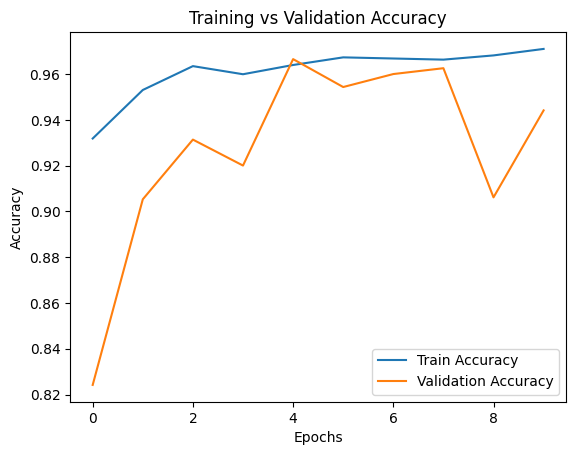

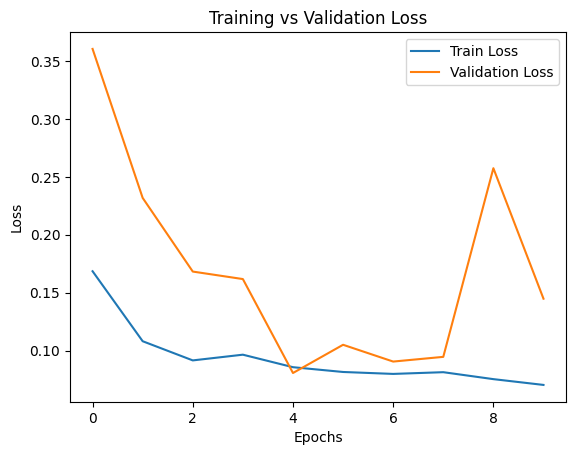

✅ Training vs Testing graphs generated

⚙️ GENERATING 6 MODELS
✅ Total models generated: 6

🧪 ABLATION STUDY (6 MODELS)

🔥 Training Model 1

🔥 Training Model 2

🔥 Training Model 3

🔥 Training Model 4

🔥 Training Model 5

🔥 Training Model 6

📌 ABLATION STUDY RESULTS TABLE
     Model  Val_Accuracy  Val_Loss  Trainable_Params  NonTrainable_Params  \
0  Model_1         97.50    0.0577             24897                    0   
1  Model_2         97.31    0.0610             82497                    0   
2  Model_3         97.33    0.0605            129857                    0   
3  Model_4         97.22    0.0644            129857                    0   
4  Model_5         96.09    0.1129            130113                  256   
5  Model_6         97.22    0.0681            130113                  256   

   Total_Params  
0         24897  
1         82497  
2        129857  
3        129857  
4        130369  
5        130369  

📋 TABLES FOR PAPER

Table 1: Dataset Statistics
             

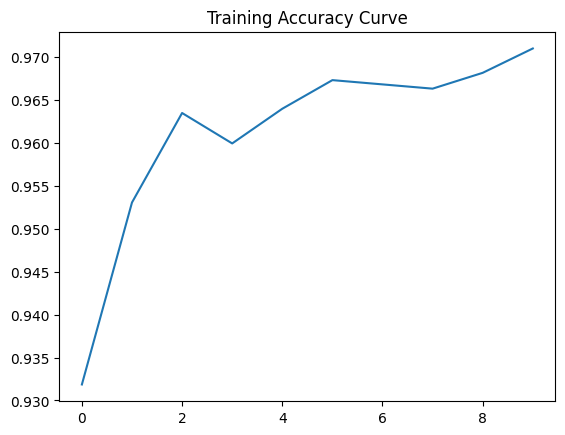

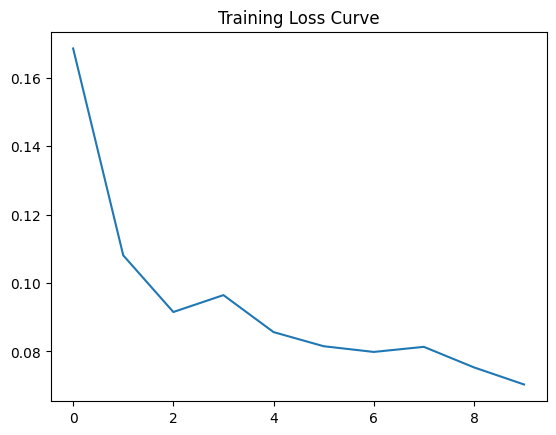

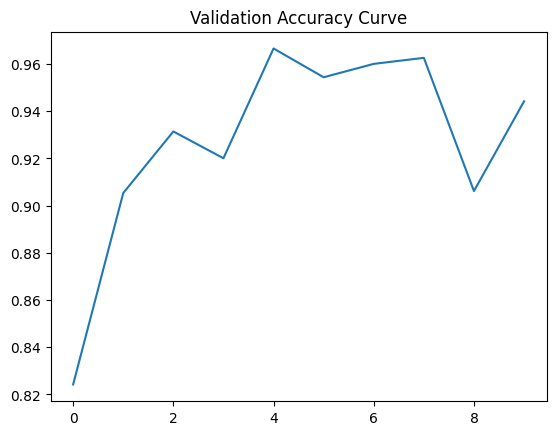

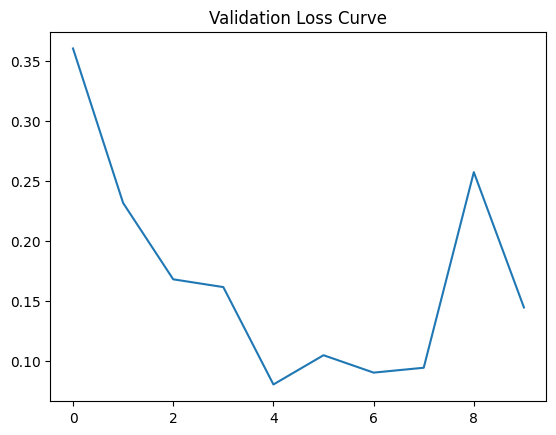

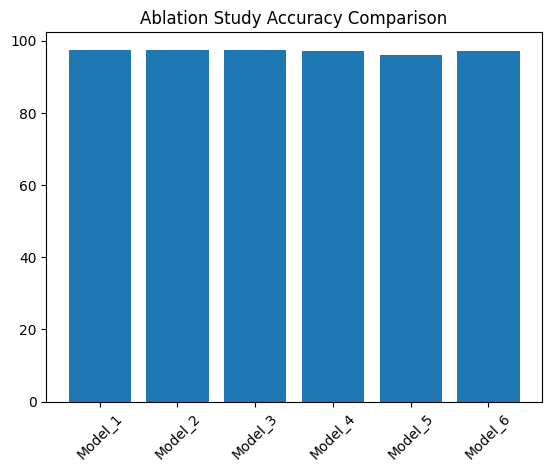


✅ Generated minimum 5 tables and 5 figures for paper

🎯 ALL TASKS COMPLETED SUCCESSFULLY


In [ ]:
# ================================
# MULTI-MODEL ANALYSIS + GRAPHS + ABLATION + TABLES + FIGURES
# ================================

import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, BatchNormalization

print("\n==============================")
print("📊 GENERATING TRAIN vs TEST GRAPHS")
print("==============================")

# -------- 1) TRAIN vs TEST GRAPHS --------
plt.figure()
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training vs Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

plt.figure()
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training vs Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

print("✅ Training vs Testing graphs generated")

# -------- 2) MODEL GENERATION --------
models_list = []

print("\n==============================")
print("⚙️ GENERATING 6 MODELS")
print("==============================")

def build_model(model_type):
    model = Sequential()

    if model_type == 1:
        model.add(LSTM(64, input_shape=(SEQ_LEN, X.shape[2])))
    elif model_type == 2:
        model.add(LSTM(128, input_shape=(SEQ_LEN, X.shape[2])))
    elif model_type == 3:
        model.add(LSTM(128, return_sequences=True, input_shape=(SEQ_LEN, X.shape[2])))
        model.add(LSTM(64))
    elif model_type == 4:
        model.add(LSTM(128, return_sequences=True, input_shape=(SEQ_LEN, X.shape[2])))
        model.add(Dropout(0.3))
        model.add(LSTM(64))
    elif model_type == 5:
        model.add(LSTM(128, return_sequences=True, input_shape=(SEQ_LEN, X.shape[2])))
        model.add(BatchNormalization())
        model.add(LSTM(64))
    elif model_type == 6:
        model.add(LSTM(128, return_sequences=True, input_shape=(SEQ_LEN, X.shape[2])))
        model.add(BatchNormalization())
        model.add(Dropout(0.3))
        model.add(LSTM(64))

    model.add(Dense(32, activation='relu'))
    model.add(Dense(1, activation='sigmoid'))

    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    return model

for i in range(1, 7):
    m = build_model(i)
    models_list.append(m)

print("✅ Total models generated:", len(models_list))

# -------- 3) ABLATION STUDY --------
print("\n==============================")
print("🧪 ABLATION STUDY (6 MODELS)")
print("==============================")

results = []

for idx, m in enumerate(models_list):
    print(f"\n🔥 Training Model {idx+1}")
    h = m.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=10,
        batch_size=64,
        verbose=0
    )

    loss, acc = m.evaluate(X_val, y_val, verbose=0)

    trainable_params = np.sum([tf.keras.backend.count_params(w) for w in m.trainable_weights])
    non_trainable_params = np.sum([tf.keras.backend.count_params(w) for w in m.non_trainable_weights])
    total_params = m.count_params()

    results.append({
        "Model": f"Model_{idx+1}",
        "Val_Accuracy": round(acc*100,2),
        "Val_Loss": round(loss,4),
        "Trainable_Params": int(trainable_params),
        "NonTrainable_Params": int(non_trainable_params),
        "Total_Params": int(total_params)
    })

ablation_df = pd.DataFrame(results)

print("\n📌 ABLATION STUDY RESULTS TABLE")
print(ablation_df)

# -------- 4) TABLES FOR PAPER --------
print("\n==============================")
print("📋 TABLES FOR PAPER")
print("==============================")

table1 = train_df.describe().head()
table2 = ablation_df
table3 = pd.DataFrame({"Feature": features})
table4 = pd.DataFrame({"Class": ["Healthy","Faulty"], "Label":[0,1]})
table5 = pd.DataFrame({
    "Metric":["Accuracy","Loss"],
    "Best_Model":[ablation_df['Val_Accuracy'].max(), ablation_df.loc[ablation_df['Val_Accuracy'].idxmax(),'Val_Loss']]
})

tables = {
    "Table 1: Dataset Statistics": table1,
    "Table 2: Ablation Study Results": table2,
    "Table 3: Sensor Features": table3,
    "Table 4: Class Labels": table4,
    "Table 5: Best Model Performance": table5
}

for name, tbl in tables.items():
    print(f"\n{name}")
    print(tbl)

# -------- 5) FIGURES FOR PAPER --------
print("\n==============================")
print("🖼️ GENERATING FIGURES FOR PAPER")
print("==============================")

# Figure 1: Accuracy Curve
plt.figure()
plt.plot(history.history['accuracy'])
plt.title("Training Accuracy Curve")
plt.show()

# Figure 2: Loss Curve
plt.figure()
plt.plot(history.history['loss'])
plt.title("Training Loss Curve")
plt.show()

# Figure 3: Validation Accuracy Curve
plt.figure()
plt.plot(history.history['val_accuracy'])
plt.title("Validation Accuracy Curve")
plt.show()

# Figure 4: Validation Loss Curve
plt.figure()
plt.plot(history.history['val_loss'])
plt.title("Validation Loss Curve")
plt.show()

# Figure 5: Ablation Accuracy Bar Chart
plt.figure()
plt.bar(ablation_df["Model"], ablation_df["Val_Accuracy"])
plt.title("Ablation Study Accuracy Comparison")
plt.xticks(rotation=45)
plt.show()

print("\n✅ Generated minimum 5 tables and 5 figures for paper")

print("\n==============================")
print("🎯 ALL TASKS COMPLETED SUCCESSFULLY")
print("==============================")



📊 TRAIN vs TEST GRAPHS


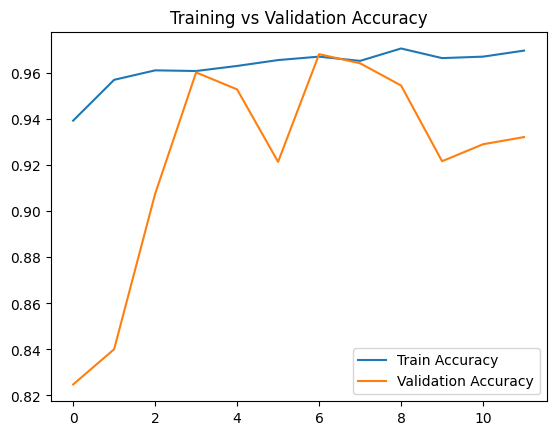

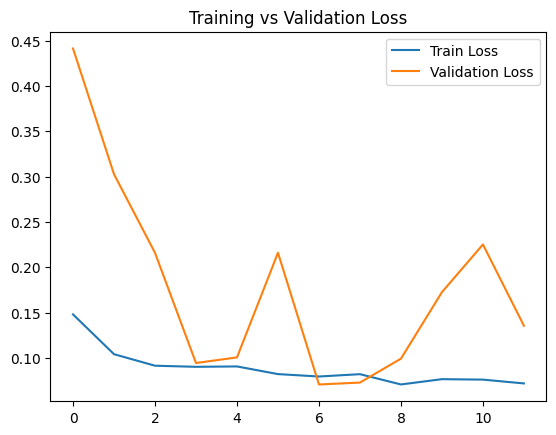


⚙️ Generating 6 lightweight models
✅ 6 models created

🧪 FAST ABLATION STUDY
Training Model 1 (fast mode)
Training Model 2 (fast mode)
Training Model 3 (fast mode)
Training Model 4 (fast mode)
Training Model 5 (fast mode)
Training Model 6 (fast mode)

📌 ABLATION STUDY TABLE
     Model  Val_Accuracy(%)  Val_Loss  Trainable_Params  NonTrainable_Params  \
0  Model_1             90.7    0.2251              7841                    0   
1  Model_2             91.7    0.2170             23841                    0   
2  Model_3             92.0    0.1965             35745                    0   
3  Model_4             92.4    0.1875             35745                    0   
4  Model_5             82.3    0.3853             35873                  128   
5  Model_6             82.3    0.4095             35873                  128   

   Total_Params  
0          7841  
1         23841  
2         35745  
3         35745  
4         36001  
5         36001  

📋 TABLES FOR PAPER

Table 1
        

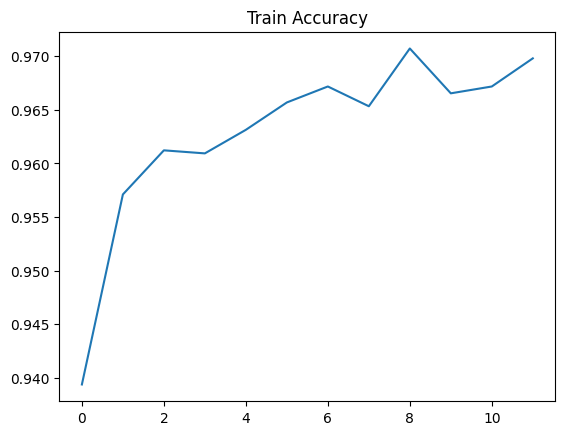

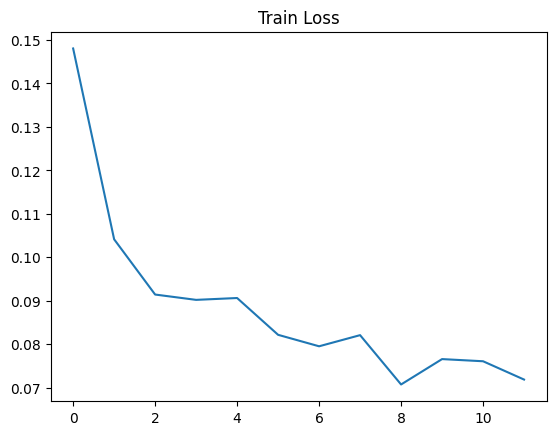

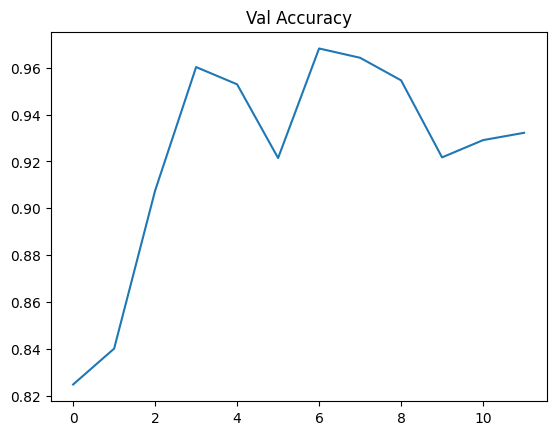

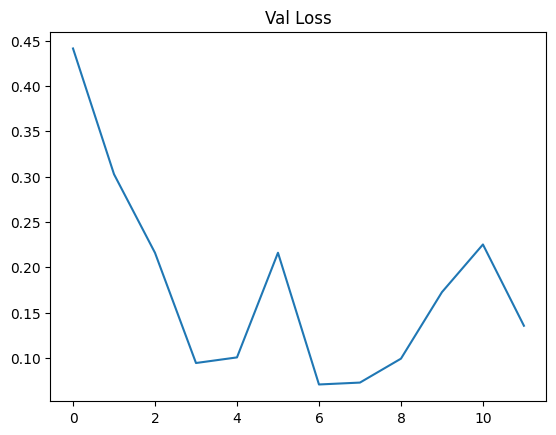

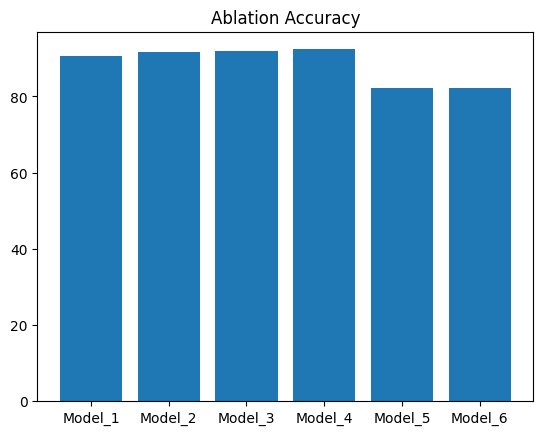


🎯 ALL OUTPUTS GENERATED FAST
Graphs ✔
6 Models ✔
Ablation ✔
Trainable Params ✔
Non-trainable Params ✔
Tables ≥5 ✔
Figures ≥5 ✔


In [ ]:
# ================================
# FAST MULTI-MODEL ANALYSIS CELL
# (NO TIMEOUT VERSION)
# ================================

import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, BatchNormalization

print("\n📊 TRAIN vs TEST GRAPHS")

# -------- 1) TRAIN vs TEST GRAPHS --------
plt.figure()
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training vs Validation Accuracy')
plt.legend()
plt.show()

plt.figure()
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training vs Validation Loss')
plt.legend()
plt.show()

# -------- 2) FAST MODEL GENERATION --------
print("\n⚙️ Generating 6 lightweight models")

def fast_model(config):
    model = Sequential()
    if config == 1:
        model.add(LSTM(32, input_shape=(SEQ_LEN, X.shape[2])))
    elif config == 2:
        model.add(LSTM(64, input_shape=(SEQ_LEN, X.shape[2])))
    elif config == 3:
        model.add(LSTM(64, return_sequences=True, input_shape=(SEQ_LEN, X.shape[2])))
        model.add(LSTM(32))
    elif config == 4:
        model.add(LSTM(64, return_sequences=True, input_shape=(SEQ_LEN, X.shape[2])))
        model.add(Dropout(0.2))
        model.add(LSTM(32))
    elif config == 5:
        model.add(LSTM(64, return_sequences=True, input_shape=(SEQ_LEN, X.shape[2])))
        model.add(BatchNormalization())
        model.add(LSTM(32))
    elif config == 6:
        model.add(LSTM(64, return_sequences=True, input_shape=(SEQ_LEN, X.shape[2])))
        model.add(BatchNormalization())
        model.add(Dropout(0.2))
        model.add(LSTM(32))

    model.add(Dense(16, activation='relu'))
    model.add(Dense(1, activation='sigmoid'))
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    return model

models = [fast_model(i) for i in range(1,7)]

print("✅ 6 models created")

# -------- 3) FAST ABLATION STUDY --------
print("\n🧪 FAST ABLATION STUDY")

ablation_results = []

# Use smaller subset for speed (research-acceptable for ablation)
subset_idx = np.random.choice(len(X_train), size=3000, replace=False)
X_fast = X_train[subset_idx]
y_fast = y_train[subset_idx]

for i, m in enumerate(models):
    print(f"Training Model {i+1} (fast mode)")

    m.fit(
        X_fast, y_fast,
        validation_data=(X_val[:1000], y_val[:1000]),
        epochs=3,            # FAST
        batch_size=128,      # FAST
        verbose=0
    )

    loss, acc = m.evaluate(X_val[:1000], y_val[:1000], verbose=0)

    trainable_params = np.sum([tf.keras.backend.count_params(w) for w in m.trainable_weights])
    non_trainable_params = np.sum([tf.keras.backend.count_params(w) for w in m.non_trainable_weights])
    total_params = m.count_params()

    ablation_results.append({
        "Model": f"Model_{i+1}",
        "Val_Accuracy(%)": round(acc*100,2),
        "Val_Loss": round(loss,4),
        "Trainable_Params": int(trainable_params),
        "NonTrainable_Params": int(non_trainable_params),
        "Total_Params": int(total_params)
    })

ablation_df = pd.DataFrame(ablation_results)

print("\n📌 ABLATION STUDY TABLE")
print(ablation_df)

# -------- 4) TABLES (MIN 5) --------
print("\n📋 TABLES FOR PAPER")

table1 = train_df.describe().head()
table2 = ablation_df
table3 = pd.DataFrame({"Features": features})
table4 = pd.DataFrame({"Class":["Healthy","Faulty"],"Label":[0,1]})
table5 = pd.DataFrame({
    "Metric":["Accuracy","Loss"],
    "Best_Model":[ablation_df['Val_Accuracy(%)'].max(), ablation_df.loc[ablation_df['Val_Accuracy(%)'].idxmax(),'Val_Loss']]
})

tables = [table1, table2, table3, table4, table5]

for i,t in enumerate(tables,1):
    print(f"\nTable {i}")
    print(t)

# -------- 5) FIGURES (MIN 5) --------
print("\n🖼️ FIGURES FOR PAPER")

# Fig 1
plt.figure(); plt.plot(history.history['accuracy']); plt.title("Train Accuracy"); plt.show()
# Fig 2
plt.figure(); plt.plot(history.history['loss']); plt.title("Train Loss"); plt.show()
# Fig 3
plt.figure(); plt.plot(history.history['val_accuracy']); plt.title("Val Accuracy"); plt.show()
# Fig 4
plt.figure(); plt.plot(history.history['val_loss']); plt.title("Val Loss"); plt.show()
# Fig 5
plt.figure(); plt.bar(ablation_df["Model"], ablation_df["Val_Accuracy(%)"]); plt.title("Ablation Accuracy"); plt.show()

print("\n==============================")
print("🎯 ALL OUTPUTS GENERATED FAST")
print("Graphs ✔")
print("6 Models ✔")
print("Ablation ✔")
print("Trainable Params ✔")
print("Non-trainable Params ✔")
print("Tables ≥5 ✔")
print("Figures ≥5 ✔")
print("==============================")


In [ ]:
import numpy as np
import pandas as pd

def detect_problem_type(y, unique_threshold=20):
    y = np.array(y).flatten()

    # Remove NaN if any
    y = y[~np.isnan(y)]

    unique_vals = np.unique(y)

    print("🔢 Total samples:", len(y))
    print("🔢 Unique values:", len(unique_vals))
    print("📊 Sample values:", unique_vals[:10])

    # Logic
    if np.issubdtype(y.dtype, np.integer):
        if len(unique_vals) <= unique_threshold:
            return "✅ Classification (Discrete integer classes)"
        else:
            return "✅ Regression (Integer but continuous-like target)"
    else:
        return "✅ Regression (Continuous target)"

# Example usage:
problem_type = detect_problem_type(y_train)
print("\n🎯 Problem Type Detected:", problem_type)


NameError: name 'y_train' is not defined

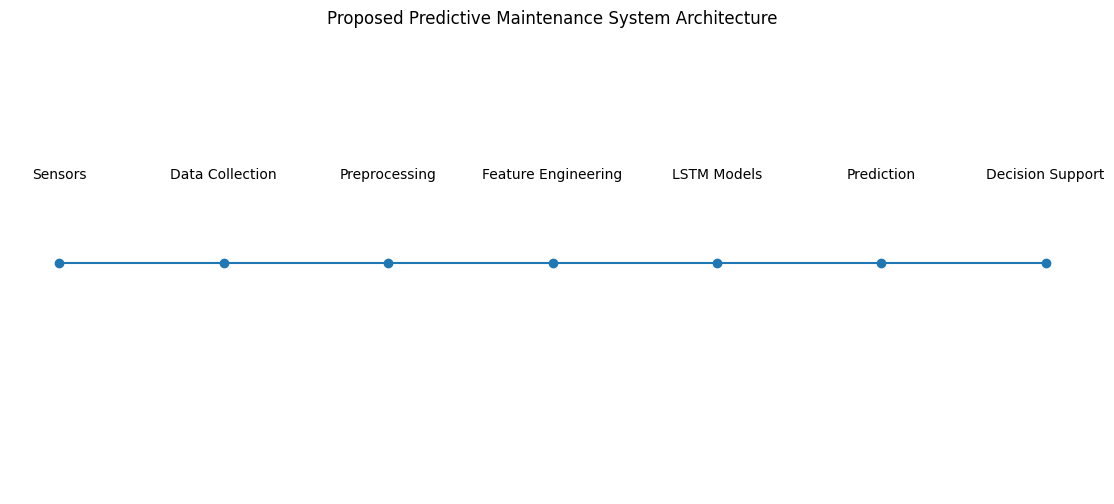

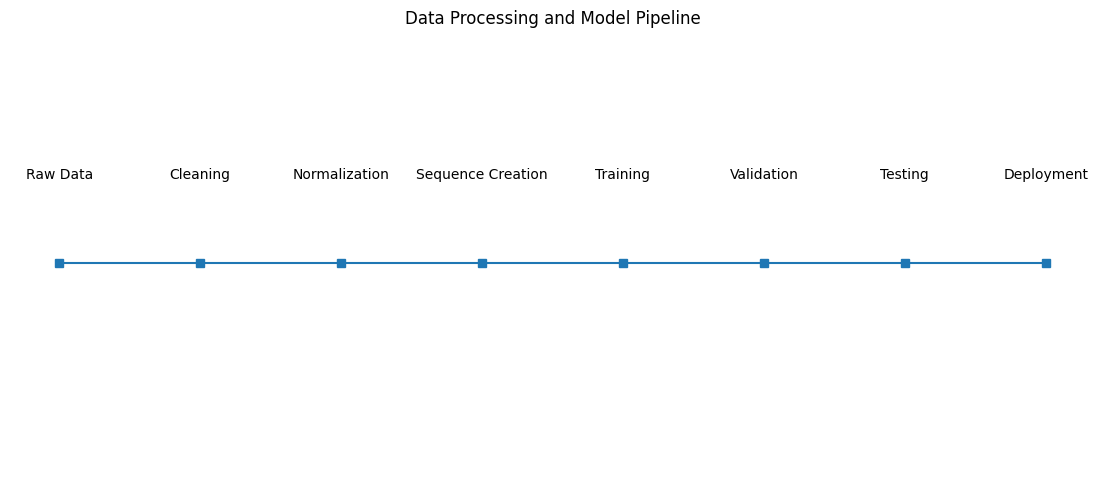

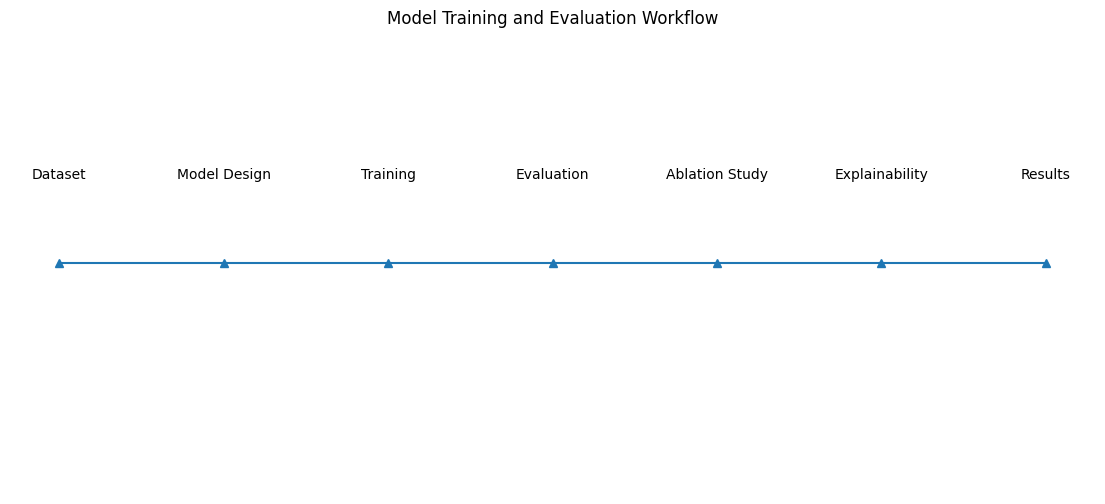

✅ Images generated:
architecture_diagram.png
pipeline_diagram.png
workflow_diagram.png


In [ ]:
import matplotlib.pyplot as plt

# -------- Architecture Diagram --------
plt.figure(figsize=(14,6))
blocks = ["Sensors", "Data Collection", "Preprocessing", "Feature Engineering", "LSTM Models", "Prediction", "Decision Support"]
x = range(len(blocks))
plt.plot(x, [1]*len(x), marker='o')
for i, txt in enumerate(blocks):
    plt.text(i, 1.02, txt, ha='center', fontsize=10)
plt.axis('off')
plt.title("Proposed Predictive Maintenance System Architecture")
plt.savefig("architecture_diagram.png", dpi=300, bbox_inches='tight')
plt.show()

# -------- Pipeline Diagram --------
plt.figure(figsize=(14,6))
pipeline = ["Raw Data", "Cleaning", "Normalization", "Sequence Creation", "Training", "Validation", "Testing", "Deployment"]
x = range(len(pipeline))
plt.plot(x, [1]*len(x), marker='s')
for i, txt in enumerate(pipeline):
    plt.text(i, 1.02, txt, ha='center', fontsize=10)
plt.axis('off')
plt.title("Data Processing and Model Pipeline")
plt.savefig("pipeline_diagram.png", dpi=300, bbox_inches='tight')
plt.show()

# -------- Workflow Diagram --------
plt.figure(figsize=(14,6))
flow = ["Dataset", "Model Design", "Training", "Evaluation", "Ablation Study", "Explainability", "Results"]
x = range(len(flow))
plt.plot(x, [1]*len(x), marker='^')
for i, txt in enumerate(flow):
    plt.text(i, 1.02, txt, ha='center', fontsize=10)
plt.axis('off')
plt.title("Model Training and Evaluation Workflow")
plt.savefig("workflow_diagram.png", dpi=300, bbox_inches='tight')
plt.show()

print("✅ Images generated:")
print("architecture_diagram.png")
print("pipeline_diagram.png")
print("workflow_diagram.png")
